## 1. Simple Linear Regression

### House Pricing Dataset

In [1]:

# from sklearn.datasets import load_boston # `load_boston` has been removed from scikit-learn since version 1.2.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
##Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [3]:

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

boston = {
    'data': data,
    'target': target,
    'feature_names': [
        'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
    ],
    'DESCR': 'Boston Housing Dataset (Original Source)'
}

print(boston['DESCR'])
print(f"Data shape: {boston['data'].shape}")
print(f"Target shape: {boston['target'].shape}")
print(f"Feature names: {boston['feature_names']}")

Boston Housing Dataset (Original Source)
Data shape: (506, 13)
Target shape: (506,)
Feature names: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [4]:

# Create DataFrame from features
dataset = pd.DataFrame(boston['data'], columns=boston['feature_names'])

# Add the target (Price) to the dataset
dataset['Price'] = boston['target']

# Display the first few rows
display(dataset.head())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### Dividing the dataset into dependent and independent features

In [5]:
x = dataset.iloc[:,:-1]   # Independent Features
y = dataset.iloc[:,-1]    # Dependent Features

In [6]:
x.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


### Linear Regression

In [7]:

lin_reg= LinearRegression()
mse= cross_val_score(lin_reg,x,y,scoring='neg_mean_squared_error',cv=5)
mean_mse= np.mean(mse)
# print(mse)
print(mean_mse)


-37.13180746769887


## Ridge Regression

In [13]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

ridge = Ridge()
parameters = {'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
# alpha is lambda which we add as penalty in cost function
ridge_regressor = GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(x,y)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   20, 30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')

In [14]:
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)

{'alpha': 100}
-29.905701947540297


In [15]:
lasso = Lasso()
parameters = {'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
# alpha is lambda which we add as penalty in cost function
lasso_regressor = GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lasso_regressor.fit(x,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.633e+03, tolerance: 3.919e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.760e+03, tolerance: 3.307e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.210e+03, tolerance: 2.814e

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   20, 30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')

In [19]:
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

{'alpha': 1}
-35.53158022069486


In [20]:
print(f"Linear Regression Mean MSE: {mean_mse}")
print(f"Ridge Regression Best Mean MSE: {ridge_regressor.best_score_}")
print(f"Lasso Regression Best Mean MSE: {lasso_regressor.best_score_}")

Linear Regression Mean MSE: -37.13180746769887
Ridge Regression Best Mean MSE: -29.905701947540297
Lasso Regression Best Mean MSE: -35.53158022069486


### 10-Fold Cross Validation Comparison

In [22]:
# Linear Regression with CV=10
mse_10 = cross_val_score(lin_reg, x, y, scoring='neg_mean_squared_error', cv=10)
mean_mse_10 = np.mean(mse_10)

# Ridge Regression with CV=10
ridge_regressor_10 = GridSearchCV(ridge, parameters, scoring='neg_mean_squared_error', cv=10)
ridge_regressor_10.fit(x, y)

# Lasso Regression with CV=10
lasso_regressor_10 = GridSearchCV(lasso, parameters, scoring='neg_mean_squared_error', cv=10)
lasso_regressor_10.fit(x, y)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.100e+03, tolerance: 4.070e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.635e+03, tolerance: 4.117e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.064e+03, tolerance: 4.124e

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.001, 0.01, 1, 5, 10,
                                   20, 30, 35, 40, 45, 50, 55, 100]},
             scoring='neg_mean_squared_error')

In [23]:
print(f"Linear Regression Mean MSE (CV=10): {mean_mse_10}")
print(f"Ridge Regression Best Mean MSE (CV=10): {ridge_regressor_10.best_score_}")
print(f"Lasso Regression Best Mean MSE (CV=10): {lasso_regressor_10.best_score_}")

Linear Regression Mean MSE (CV=10): -34.705255944524914
Ridge Regression Best Mean MSE (CV=10): -29.61522009733512
Lasso Regression Best Mean MSE (CV=10): -34.45554381307912


### Model Comparison with 77-33 Train-Test Split

In [24]:
from sklearn.metrics import mean_squared_error

# 1. Train-Test Split (77% Train, 33% Test)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

# 2. Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_pred = lin_reg.predict(X_test)
lin_mse = mean_squared_error(y_test, lin_pred)

# 3. Ridge Regression (using the best alpha from previous GridSearch or tuning here)
ridge = Ridge(alpha=100) # Using best alpha found earlier
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_mse = mean_squared_error(y_test, ridge_pred)

# 4. Lasso Regression
lasso = Lasso(alpha=1) # Using best alpha found earlier
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_pred)

# Comparison
print(f"Linear Regression MSE: {lin_mse}")
print(f"Ridge Regression MSE: {ridge_mse}")
print(f"Lasso Regression MSE: {lasso_mse}")

results = {"Linear": lin_mse, "Ridge": ridge_mse, "Lasso": lasso_mse}
best_model = min(results, key=results.get)
print(f"\nThe best model based on test MSE is: {best_model}")

Linear Regression MSE: 20.724023437339635
Ridge Regression MSE: 22.93210078445747
Lasso Regression MSE: 25.372280929902782

The best model based on test MSE is: Linear


### Model Comparison: R-squared and Adjusted R-squared

Adjusted R-squared formula:
$R^2_{adj} = 1 - [\frac{(1 - R^2)(n - 1)}{n - k - 1}]$
where $n$ is the number of samples and $k$ is the number of features.

In [25]:
def get_adj_r2(r2, n, k):
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

n = len(y_test)
k = X_test.shape[1]

# Calculate R2 scores
lin_r2 = r2_score(y_test, lin_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

# Calculate Adjusted R2 scores
lin_adj = get_adj_r2(lin_r2, n, k)
ridge_adj = get_adj_r2(ridge_r2, n, k)
lasso_adj = get_adj_r2(lasso_r2, n, k)

# Create a comparison table
comparison_metrics = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso'],
    'MSE': [lin_mse, ridge_mse, lasso_mse],
    'R-squared': [lin_r2, ridge_r2, lasso_r2],
    'Adjusted R-squared': [lin_adj, ridge_adj, lasso_adj]
})

display(comparison_metrics)

,Model,MSE,R-squared,Adjusted R-squared
0,Linear,20.724023,0.726157,0.702889
1,Ridge,22.932101,0.696980,0.671233
2,Lasso,25.372281,0.664736,0.636249


## 2. Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [32]:
df = load_breast_cancer()

# Indepoendent Features
x = pd.DataFrame(df['data'], columns=df['feature_names'])

# Dependent Feature
y = pd.DataFrame(df['target'], columns=['Target'])

In [31]:
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [33]:
y

,Target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [34]:
y['Target'].value_counts()

,count
Target,
1,357
0,212


In [41]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (381, 30)
Testing set shape: (188, 30)


In [43]:
params = [{'C':[1,5,10]},{'max_iter':[100,150]}]

In [42]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model on scaled data
classifier = LogisticRegression()
classifier.fit(X_train_scaled, y_train.values.ravel())

# Make predictions
y_pred = classifier.predict(X_test_scaled)

print("Model trained on scaled data and predictions made successfully.")

Model trained on scaled data and predictions made successfully.


In [40]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Evaluate the model
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy Score: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(report)

Accuracy Score: 0.9737

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



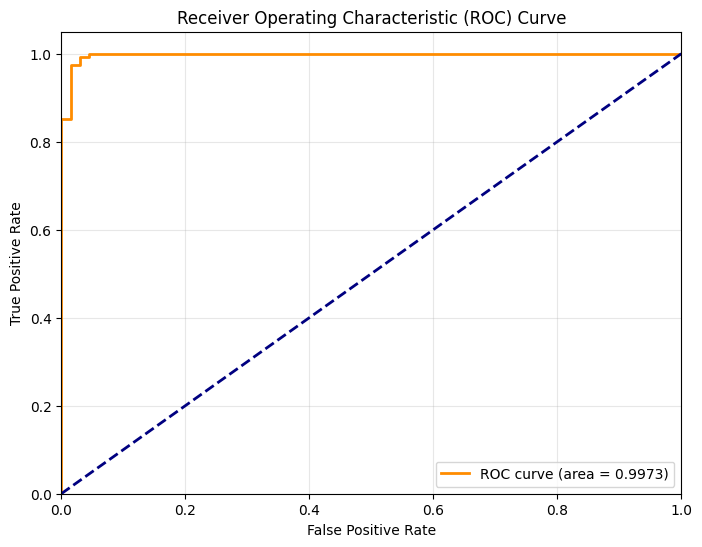

ROC-AUC Score: 0.9973


In [45]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability scores for the positive class
y_prob = classifier.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")